# Final-Project-Code-Group-1
## [https://github.com/mr-kelsey/sp26-aai530-group1](https://github.com/mr-kelsey/sp26-aai530-group1)

### Parts:
* Data processing: Nicholson
* Machine Learning:
	* Time series: Johnathan
	* Deep learning: Tushar

# Code

In [1]:
"""Imports"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from keras.callbacks import EarlyStopping
from keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from keras.models import Sequential
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [2]:
"""Load up the raw data, converting European data format to US standards"""
path_to_file = Path(Path.cwd().parent, "Data", "AirQualityUCI.csv")
raw = pd.read_csv(path_to_file, delimiter=";", decimal=",")
raw = raw.loc[:, ~raw.columns.str.contains("^Unnamed")]
raw_sensor = (
    raw
    .rename(columns={"T" : "Temperature (C)",
                    "RH" : "Relative Humidity",
                    "AH" : "Absolute Humidity"})
).iloc[:9357]

raw_sensor.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Temperature (C),Relative Humidity,Absolute Humidity
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
"""Fix Date and time formatting and data type"""
sensors = raw_sensor.copy()
sensors["Time"] = sensors["Time"].str.replace(".", ":", regex=False)
sensors["Datetime"] = pd.to_datetime(
    sensors[["Date", "Time"]]
    .apply(lambda x:
           " ".join(x.values.astype(str)),
           axis="columns"),
           dayfirst=True)

sensors["Date"] = sensors["Datetime"].dt.date
sensors["Time"] = sensors["Datetime"].dt.time

sensors = sensors.drop(["Date", "Time"], axis=1)
sensors.dtypes

,0
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64
PT08.S4(NO2),float64
PT08.S5(O3),float64


 ## Data Processing

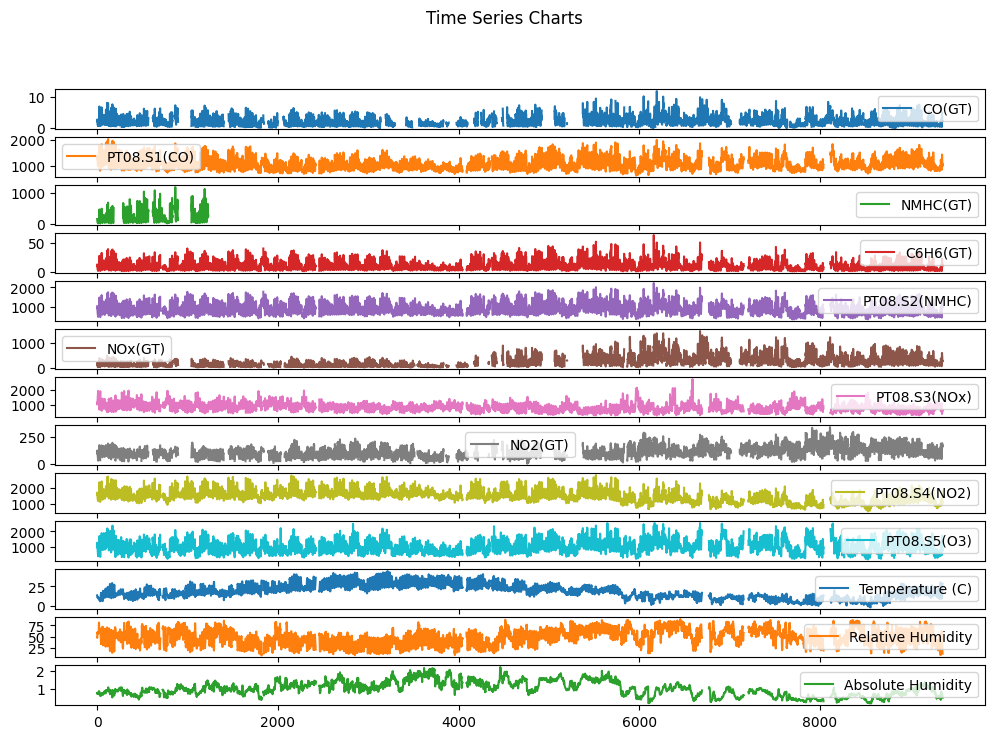

In [4]:
"""Convert -200 values to NaN and plot the data"""
numeric_cols = sensors.select_dtypes(include=[np.number]).columns

sensors.replace(-200, np.nan, inplace=True)

sensors[numeric_cols].plot(
    subplots=True,
    figsize=(12, 8),
    title="Time Series Charts"
)
plt.show()

In [5]:
"""Get count of missing datapoints for each sensor"""
print("NaNs per column:\n", sensors.isna().sum().sort_values(ascending=False).head(20))

NaNs per column:
 NMHC(GT)             8443
CO(GT)               1683
NO2(GT)              1642
NOx(GT)              1639
C6H6(GT)              366
PT08.S1(CO)           366
PT08.S2(NMHC)         366
PT08.S3(NOx)          366
PT08.S4(NO2)          366
PT08.S5(O3)           366
Temperature (C)       366
Relative Humidity     366
Absolute Humidity     366
Datetime                0
dtype: int64


In [6]:
"""Add time features"""
sensors["hour"] = sensors["Datetime"].dt.hour
sensors["dayofweek"] = sensors["Datetime"].dt.dayofweek
sensors["month"] = sensors["Datetime"].dt.month

sensors[["hour", "dayofweek", "month"]].head()

,hour,dayofweek,month
0,18,2,3
1,19,2,3
2,20,2,3
3,21,2,3
4,22,2,3


In [7]:
"""Create training data from existing data and train model for imputation"""
na_counts = sensors[numeric_cols].isna().sum().sort_values(ascending=False)

for target in na_counts[na_counts > 0].index:
    n_missing = int(na_counts[target])

    train = (
        sensors[sensors[target].notna()]
        .drop(["Datetime"], axis=1)
	)
    missing = (
        sensors[sensors[target].isna()]
        .drop(["Datetime"], axis=1)
	)

    X_train = train.drop(columns=[target])
    y_train = train[target]
    X_missing = missing.drop(columns=[target])

    model = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=600,
            max_depth=16,
            min_samples_leaf=2,
            random_state=0,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)
    sensors.loc[missing.index, target] = model.predict(X_missing)

    print(f"{target}: impute-baby! ({n_missing} missing)")

NMHC(GT): impute-baby! (8443 missing)
CO(GT): impute-baby! (1683 missing)
NO2(GT): impute-baby! (1642 missing)
NOx(GT): impute-baby! (1639 missing)
PT08.S1(CO): impute-baby! (366 missing)
PT08.S2(NMHC): impute-baby! (366 missing)
C6H6(GT): impute-baby! (366 missing)
PT08.S3(NOx): impute-baby! (366 missing)
PT08.S4(NO2): impute-baby! (366 missing)
PT08.S5(O3): impute-baby! (366 missing)
Temperature (C): impute-baby! (366 missing)
Relative Humidity: impute-baby! (366 missing)
Absolute Humidity: impute-baby! (366 missing)


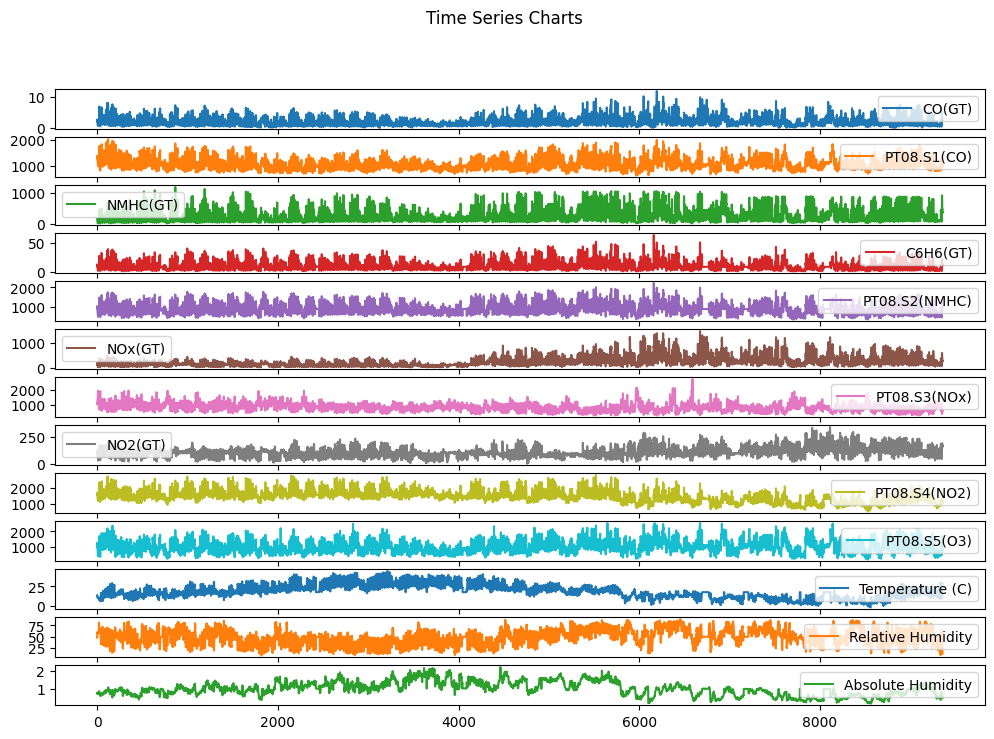

In [8]:
"""Verify imputation"""
sensors[numeric_cols].plot(
    subplots=True,
    figsize=(12, 8),
    title="Time Series Charts"
)
plt.show()

## Time Series

In [9]:
"""Filter the data to readings only and convert datetime to unix epoch"""
readings = (
	sensors
	.filter(["Datetime", "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"])
)
readings["unix"] = readings["Datetime"].apply(lambda x: x.timestamp())
readings.head()

,Datetime,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),unix
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,1.078942e+09
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,1.078945e+09
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,1.078949e+09
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,1.078952e+09
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,1.078956e+09


In [10]:
"""Setup data and train linear regression model to to use as timeseries prediction model"""
predictions = {}
for column in readings.columns:
	if column not in ["Datetime", "unix"]:
		time_series = pd.DataFrame(readings.unix)
		sensor_values = pd.DataFrame(readings.filter([column]))

		number_of_samples = len(time_series)
		prediction_horizon = 24 * 3600 # 24 hours
		mu = 0.9

		tp_pred = np.zeros(number_of_samples - 1)
		yp_pred = np.zeros(number_of_samples - 1)

		for i in range(2, number_of_samples + 1):
			ts_tmp = time_series[0:i]
			ys_tmp = sensor_values[0:i]
			ns = len(ys_tmp)

			weights = np.ones(ns) * mu
			for k in range(ns):
				weights[k] = weights[k] ** k
			weights = np.flip(weights, 0)

			lm_tmp = LinearRegression()
			model_tmp = lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

			m_tmp = model_tmp.coef_
			q_tmp = model_tmp.intercept_

			tp = time_series.iloc[i-1, 0] + prediction_horizon
			yp = m_tmp * tp + q_tmp

			tp_pred[i-2] = tp
			yp_pred[i-2] = yp.item()

		# floor of zero because negative numbers don't makes sense in the context
		yp_pred = np.where(yp_pred < 0, 0, yp_pred)
		predictions[column] = yp_pred

predictions

{'PT08.S1(CO)': array([   0.        , 1954.36598891, 1780.25629144, ..., 1436.92216135,
        1356.2025342 , 1316.52761087]),
 'PT08.S2(NMHC)': array([   0.        ,    0.        ,  234.68187265, ..., 1347.34913278,
        1333.95622756, 1356.35841206]),
 'PT08.S3(NOx)': array([4005.99999999, 2106.6987061 , 1216.38363825, ...,  349.1967581 ,
         378.21312575,  384.31425229]),
 'PT08.S4(NO2)': array([   0.        ,    0.        ,  847.12766637, ..., 1678.91413251,
        1560.6830996 , 1497.55913195]),
 'PT08.S5(O3)': array([   0.        ,    0.        , 1116.78133738, ..., 1919.33023855,
        1708.71745776, 1548.51393075])}

In [11]:
"""Extend our timestamps and align predictions"""
start = readings.iloc[-1]["Datetime"] + pd.Timedelta(hours=1)
end = start + pd.Timedelta(hours=23)

extended_timeline = pd.date_range(start=start, end=end, freq="h")

prediction_df = pd.concat(
    [readings.drop("unix", axis=1),
     pd.DataFrame({
         "Datetime": extended_timeline,
         "PT08.S1(CO)": np.nan,
         "PT08.S2(NMHC)": np.nan,
         "PT08.S3(NOx)": np.nan,
         "PT08.S4(NO2)": np.nan,
         "PT08.S5(O3)": np.nan
         },
         index=np.arange(9357, 9381))])

for sensor, preds in predictions.items():
    chemical = sensor[sensor.index("(") + 1 : sensor.index(")")]
    prediction_df[f"{chemical}_prediction"] = np.concatenate([np.full(25, np.nan), preds])

prediction_df

,Datetime,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),CO_prediction,NMHC_prediction,NOx_prediction,NO2_prediction,O3_prediction
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,NaN,NaN,NaN,NaN,NaN
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,NaN,NaN,NaN,NaN,NaN
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,NaN,NaN,NaN,NaN,NaN
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,NaN,NaN,NaN,NaN,NaN
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
9376,2005-04-05 10:00:00,NaN,NaN,NaN,NaN,NaN,1471.776087,1271.118249,395.958841,1737.993084,1992.590849
9377,2005-04-05 11:00:00,NaN,NaN,NaN,NaN,NaN,1459.144884,1306.224952,369.063011,1713.299184,1998.193792
9378,2005-04-05 12:00:00,NaN,NaN,NaN,NaN,NaN,1436.922161,1347.349133,349.196758,1678.914133,1919.330239
9379,2005-04-05 13:00:00,NaN,NaN,NaN,NaN,NaN,1356.202534,1333.956228,378.213126,1560.683100,1708.717458


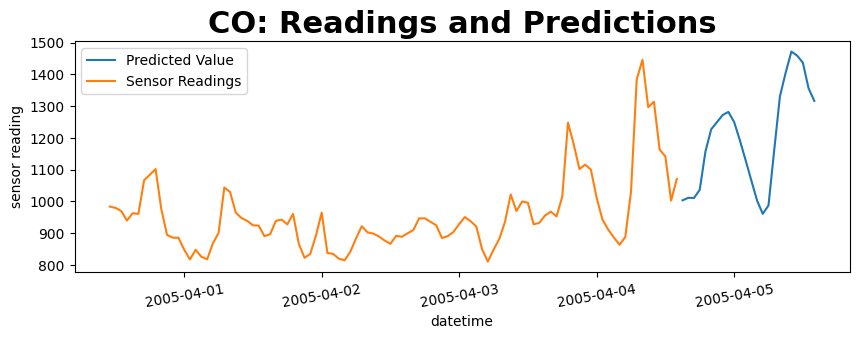

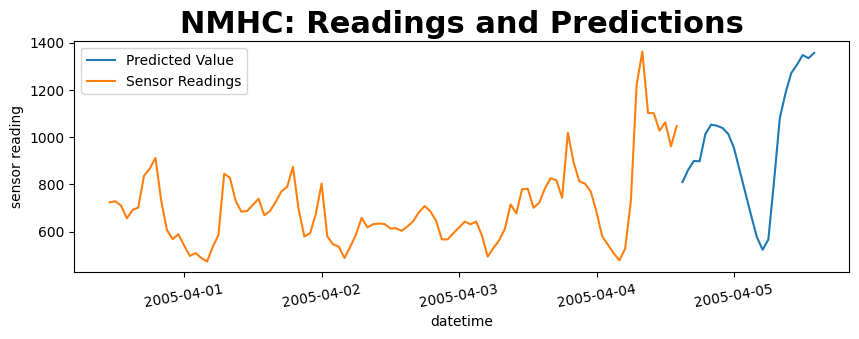

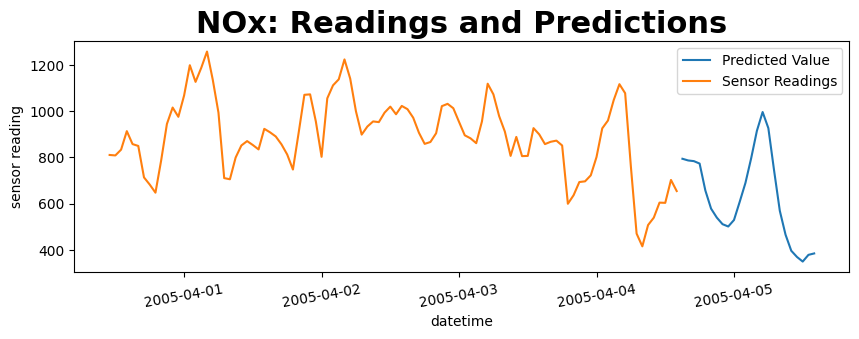

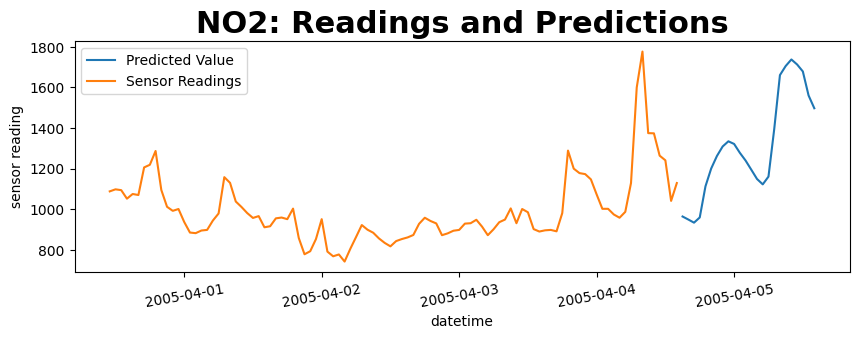

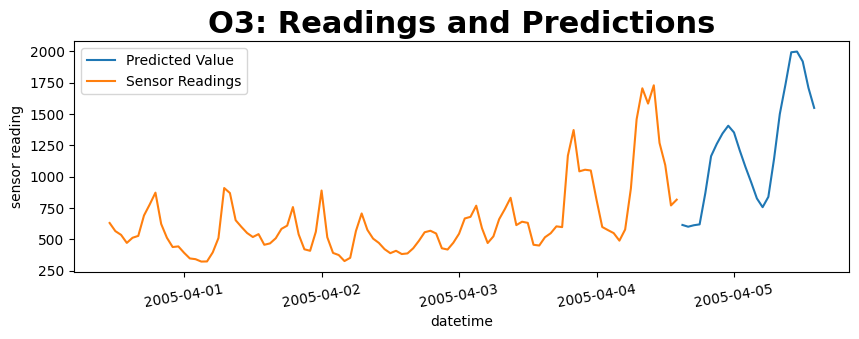

In [12]:
"""Visualize prediction dataframe"""
timestamps = prediction_df["Datetime"]

for sensor_column in ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]:
	chemical = sensor_column[sensor_column.index("(") + 1 : sensor_column.index(")")]
	sensor = prediction_df[sensor_column]
	preds = prediction_df[f"{chemical}_prediction"]

	fig, ax = plt.subplots(figsize=(10,3))
	ax.set_title(f"{chemical}: Readings and Predictions", fontsize=22, fontweight='bold')
	ax.set_ylabel("sensor reading")
	ax.set_xlabel("datetime")


	ax.plot(timestamps[-24:], preds[-24:], label='Predicted Value')
	ax.plot(timestamps[-124:-24], sensor[-124:-24], label='Sensor Readings')
	ax.legend()

	plt.xticks(rotation=10)
	plt.show()

## Deep Learning

In [13]:
"""Filter dataframe and normalize the data for each sensor"""
normalized = (
    sensors
    .filter(["CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "PT08.S2(NMHC)", "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)", "C6H6(GT)", "PT08.S5(O3)"])
)
numeric_cols = normalized.select_dtypes(include=[np.number]).columns

for column in numeric_cols:
    minimum = normalized[column].min()
    maximum = normalized[column].max()
    if maximum != minimum:
        normalized[column] = (normalized[column] - minimum) / (maximum - minimum)

normalized.head()

,CO(GT),PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),C6H6(GT),PT08.S5(O3)
0,0.211864,0.511845,0.120981,0.362097,0.111036,0.310885,0.328402,0.513040,0.185535,0.454822
1,0.161017,0.463029,0.088832,0.312398,0.068382,0.360864,0.266272,0.453237,0.146226,0.326238
2,0.177966,0.541996,0.068528,0.303659,0.087339,0.346463,0.331361,0.451439,0.139937,0.370547
3,0.177966,0.523331,0.061760,0.308575,0.115098,0.326133,0.355030,0.464478,0.143082,0.426586
4,0.127119,0.448672,0.037225,0.247406,0.087339,0.373994,0.337278,0.422212,0.100629,0.386186


In [14]:
"""Group sensors by chemicals and break data into week long sequences of readings"""
grouped_by_chemical = {}
seq_length = 7 * 24

for certified, test in [("CO(GT)", "PT08.S1(CO)"), ("NMHC(GT)", "PT08.S2(NMHC)"), ("NOx(GT)", "PT08.S3(NOx)"), ("NO2(GT)", "PT08.S4(NO2)"), ("C6H6(GT)", "PT08.S5(O3)")]:
	training_data = (
		normalized[certified]
		.astype(np.float32)
	)
	testing_data = (
		normalized[test]
		.astype(np.float32)
	)

	training = np.array([training_data[i:i + seq_length] for i in range(len(training_data) - seq_length)], dtype=np.float32)
	testing = np.array([testing_data[i:i + seq_length] for i in range(len(testing_data) - seq_length)], dtype=np.float32)

	chemical = certified.split("(")[0]
	chemical = chemical if chemical != "C6H6" else "O3"
	grouped_by_chemical[chemical] = (training, testing)

grouped_by_chemical.keys()

dict_keys(['CO', 'NMHC', 'NOx', 'NO2', 'O3'])

In [15]:
"""Build out and train auto encoder"""
autoencoder = Sequential()
autoencoder.add(Input(shape=(seq_length, 1)))
autoencoder.add(LSTM(16, return_sequences=False))
autoencoder.add(RepeatVector(seq_length))
autoencoder.add(LSTM(16, return_sequences=True))
autoencoder.add(TimeDistributed(Dense(1)))
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 168, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 168, 16)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 168, 1)         │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

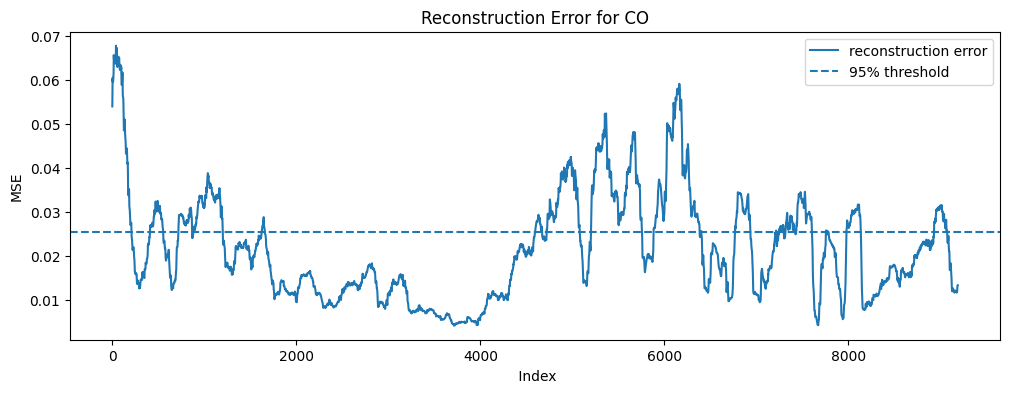

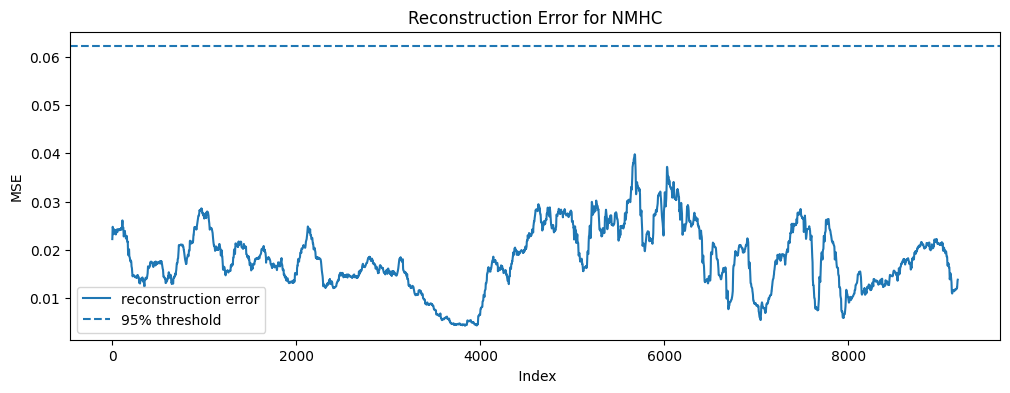

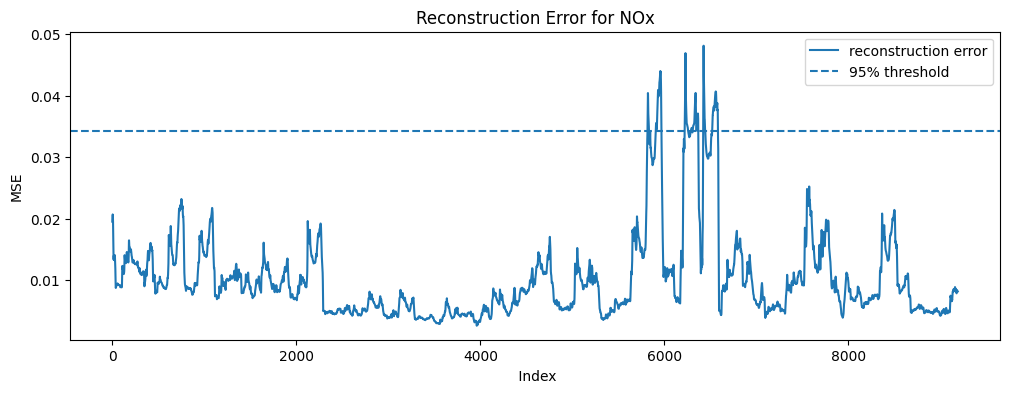

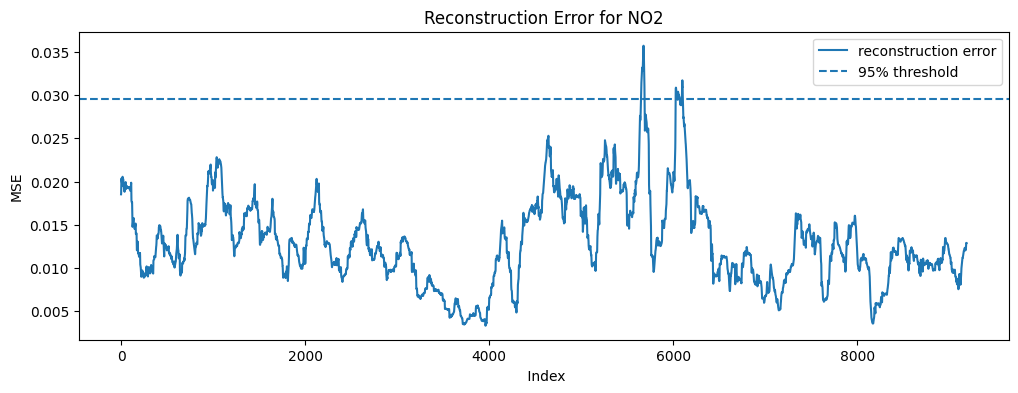

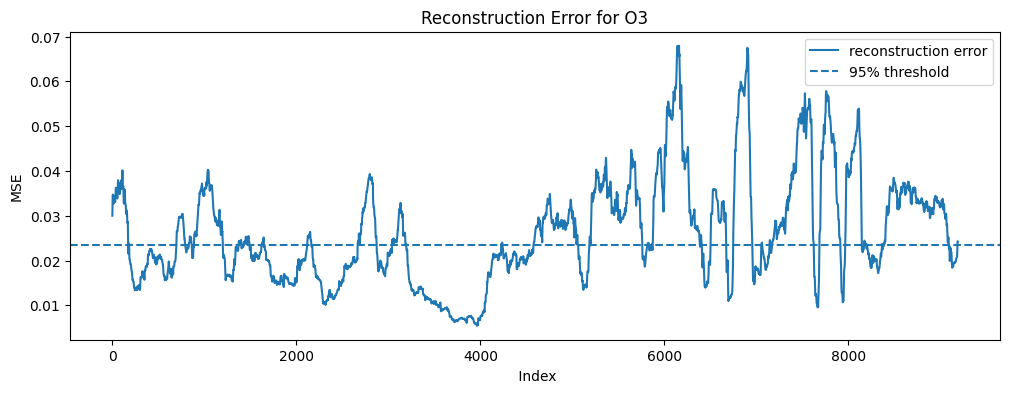

In [16]:
"""Fit AE on each chemical and vizualize anomaly points"""
for chemical, (seq_arrays, val_arrays) in grouped_by_chemical.items():
	history = autoencoder.fit(
	    seq_arrays, seq_arrays, epochs=100, batch_size=500, validation_split=0.05 ,verbose=0,
	    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
	)

	train_recon = autoencoder.predict(seq_arrays, verbose=0)
	train_rec_err = np.mean((train_recon - np.expand_dims(seq_arrays, axis=-1)) ** 2, axis=(1, 2))
	threshold = np.percentile(train_rec_err, 95)

	val_recon = autoencoder.predict(val_arrays, verbose=0)
	val_rec_err = np.mean((val_recon - np.expand_dims(val_arrays, axis=1)) ** 2, axis=(1, 2))
	anomaly_idx = np.where(val_rec_err > threshold)[0]

	plt.figure(figsize=(12, 4))
	plt.plot(val_rec_err, label="reconstruction error")
	plt.axhline(threshold, linestyle="--", label="95% threshold")
	plt.legend()
	plt.title(f"Reconstruction Error for {chemical}")
	plt.xlabel(" Index")
	plt.ylabel("MSE")
	plt.show()
